### PERSEO - PERturbed Stellar Elements and Orbits
This code implements the method of Gauss equations to compute the three components of the acceleration R, S, W in the frame co-moving with the star $\{\mathbf{n}, \boldsymbol{\lambda}, \mathbf{z}\}$ and uses them to solve the osculating equations of the orbital elements $\mu_i = \{p, e, i, \omega, \Omega\}$ as $\frac{d\mu_i}{df} = \frac{d\mu_i}{dt} \frac{dt}{df}$, over one orbit. 

The angles $\{i, \omega, \Omega\}$ are defined in the frame of the observer $\{\mathbf{x}_{\text{obs}}, \mathbf{y}_{\text{obs}}, \mathbf{z}_{\text{obs}}\}$ and $\omega$ and $\Omega$ differ by a factor $\pi$ from those reported in GRAVITY (2025) due to different conventions (see Foschi et al. (2026)).

The perturbing accelerations currently implemented in the code are: 1 PN, 1.5 PN, Plummer density profile, ring with uniform density, disk with power law density, scalar cloud on the equatorial plane of the BH, vector cloud.  

In [1]:
import numpy as np
from perseo import *
from perseo.constants import Msun, degree_to_rad

#### Physical parameters
If constants.py is imported entirely, the orbital elements $p,e,i_{\text{orb}}, \omega, \Omega$ are those of S2, $M$ is SgrA$^*$ mass and $R0$ is the GC distance [from GRAVITY 2025]. 

In [2]:
M = 4.29e6*Msun              # Sgr A* mass [kg]
a = 1.5e14                   # semi-major axis [m]
e = 0.88
p = a*(1-e**2) 
iORB = 134.7*degree_to_rad
omega = 66.3*degree_to_rad + np.pi
Omega = 228.2*degree_to_rad + np.pi #note the shift by a factor pi as explained in Foschi et al. (2026)

elements0 = (p, e, iORB, omega, Omega)   # p, e, i, omega, Omega


#### Integrates the orbit and computes the difference with initial parameters in elements0

Here p is converted from [m] to [as] using the current estimate for the GC distance R0 while angles can be converted into [as] or [deg] depending on [angle_units]

In [6]:
perturbations = [make_onePN(M)]
f, y = integrate_orbit(elements0, perturbations, M)

d = element_changes(f, y, elements0, angle_units='deg')
print("pericentre advance over one orbit:", d['omega'][-1], "deg")

pericentre advance over one orbit: 0.20184562638661221 deg


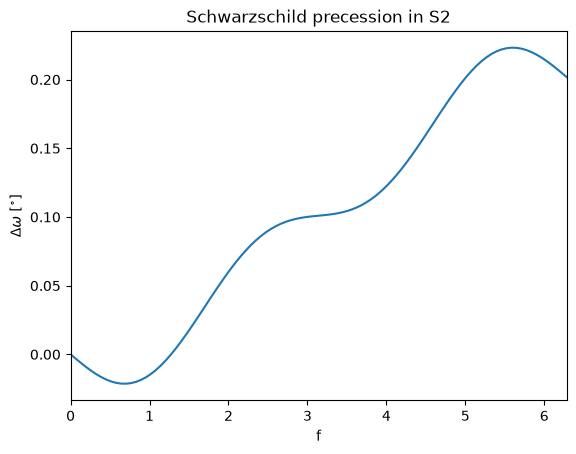

In [8]:
plt.plot(f, d["omega"])
plt.xlabel("f")
plt.ylabel("$\\Delta \\omega$ $[^{\\circ}]$")
plt.title("Schwarzschild precession in S2")
plt.xlim(0, 2*np.pi)
plt.show()